# Lossy Compression for WRF
This notebook will compare the data compressed using lossy compression to the original file using a single time slice as an example. 

# Summary of Compression

Precision preserving Compression (PPC) <br>

NetCDF4 format (-7)
    + Deflate compression (-L 4)          → Smaller file size<br>
    + PPC bit-rounding (--ppc)            → Further size reduction<br>
         ├── Core dynamics → 6 digits     → High precision preserved<br>
         ├── Fluxes/precip → 5 digits     → Moderate precision<br>
         └── Everything else → 4 digits   → Default (maximum compression)<br>

##  How does it work?
### Example
Original:   273.15948372...   (all 23 mantissa bits used)<br>
--ppc T=4:  273.2             (only bits needed for 4 sig. digits kept)<br>
--ppc T=6:  273.159           (only bits needed for 6 sig. digits kept)<br>

Before PPC:   101101110101001110101011   ← random-looking bits, hard to compress <br>
After PPC:    101101110101000000000000   ← trailing zeros compress very efficiently <br>

         
The code for d03 <br>
ncks -7 -L 4 \
  --ppc default=4 \
  --ppc Q2=6 --ppc QVAPOR=6 \
  --ppc PSFC=6 --ppc T2=5 --ppc T=5 --ppc THM=5 \
  --ppc U10=6 --ppc V10=6 --ppc U=6 --ppc V=6 \
  --ppc P=6 --ppc P_HYD=6 \
  --ppc PH=6 --ppc W=6 \
  --ppc HFX=5 --ppc LH=5 \
  --ppc RAINNC=5 --ppc SNOWNC=5 --ppc SNOW=5 \
  -x -v PB,PHB,CLAT,XLAND,AREA2D,DX2D,TMN,CF1,CF2,CF3,RAINC,RAINSH,DUSFCG,DVSFCG,HAILNC,ISEEDARRAY_SPP_CONV,ISEEDARRAY_SPP_LSM,ISEEDARRAY_SPP_PBL,ISEEDARR_RAND_PERTURB,ISEEDARR_SKEBS,ISEEDARR_SPPT,I_ACLWDNT,I_ACLWDNTC,I_RAINC,RESM,ZETATOP,SST_INPUT,SSTSK,SWNORM,THIS_IS_AN_IDEAL_RUN,SAVE_TOPO_FROM_REAL \
  \"\$infile\" \"\$outfile\"

  The constants are stored in a separate file - variables that are all zero are removed.
  


## Application

In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import pandas as pd
from IPython.display import display, HTML
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

print("✅ Libraries imported successfully")

✅ Libraries imported successfully


In [2]:
# ============================================================================
# FILE PATHS

file0 = 'wrfout_d03_1986-11-23_03:00:00'
#filename = "/gpfs/fs7/dfo/hpcmc/pfm/spfm000/amh001/WRF-Tests/"+file0
ORIGINAL_DIR='/home/spfm000/evg000/CanESM2_WRF_runs/historical_r1i1p1_1986/WRF/'
ORIGINAL_FILE=f'{ORIGINAL_DIR}{file0}'
file1=f'CanESM2-WRF{file0[6:]}.nc'
COMPRESSED_DIR='/gpfs/fs7/dfo/hpcmc/pfm/spfm000/DATA/CanESM2-WRF-2026/1986/'
COMPRESSED_FILE  =f"{COMPRESSED_DIR}{file1}"

#"/gpfs/fs7/dfo/hpcmc/pfm/spfm000/amh001/WRF-Tests/wrf_ppc_5rad_6TP_d4.nc"



print(f"Configuration:")
print(f"  Original file:   {ORIGINAL_FILE}")
print(f"  Compressed file: {COMPRESSED_FILE}")


Configuration:
  Original file:   /home/spfm000/evg000/CanESM2_WRF_runs/historical_r1i1p1_1986/WRF/wrfout_d03_1986-11-23_03:00:00
  Compressed file: /gpfs/fs7/dfo/hpcmc/pfm/spfm000/DATA/CanESM2-WRF-2026/1986/CanESM2-WRF_d03_1986-11-23_03:00:00.nc


In [3]:
# ============================================================================
# LOAD NETCDF FILES
# ============================================================================

print("Loading NetCDF files...")
try:
    orig = xr.open_dataset(ORIGINAL_FILE)
    comp = xr.open_dataset(COMPRESSED_FILE)
    print(f"✅ Original file loaded: {len(orig.data_vars)} variables")
    print(f"✅ Compressed file loaded: {len(comp.data_vars)} variables")
    
    # Show dimensions
    print(f"\nDimensions:")
    for dim, size in orig.dims.items():
        print(f"  {dim}: {size}")
        
except Exception as e:
    print(f"❌ Error loading files: {e}")
    raise

Loading NetCDF files...
✅ Original file loaded: 136 variables
✅ Compressed file loaded: 105 variables

Dimensions:
  Time: 1
  south_north: 300
  west_east: 300
  bottom_top: 50
  west_east_stag: 301
  south_north_stag: 301
  bottom_top_stag: 51
  seed_dim_stag: 2


In [4]:
# ============================================================================
# VARIABLES TO VALIDATE
# ============================================================================

VARIABLES_TO_CHECK = {
    # Core thermodynamic variables
    'Q2': {'precision': 6, 'importance': 'CRITICAL', 'units': 'kg/kg', 'description': '2-m mixing ratio'},
    'QVAPOR': {'precision': 6, 'importance': 'CRITICAL', 'units': 'kg/kg', 'description': '3D water vapor'},
    'T2': {'precision': 6, 'importance': 'CRITICAL', 'units': 'K', 'description': '2-m temperature'},
    'T': {'precision': 6, 'importance': 'CRITICAL', 'units': 'K', 'description': 'Potential temperature'},
    'THM': {'precision': 6, 'importance': 'HIGH', 'units': 'K', 'description': 'Moist potential temperature'},
    
    # Pressure variables
    'PSFC': {'precision': 7, 'importance': 'CRITICAL', 'units': 'Pa', 'description': 'Surface pressure'},
    'P': {'precision': 6, 'importance': 'CRITICAL', 'units': 'Pa', 'description': 'Pressure perturbation'},
    'PB': {'precision': 6, 'importance': 'CRITICAL', 'units': 'Pa', 'description': 'Base state pressure'},
    'P_HYD': {'precision': 6, 'importance': 'HIGH', 'units': 'Pa', 'description': 'Hydrostatic pressure'},
    
    # Geopotential
    'PH': {'precision': 6, 'importance': 'CRITICAL', 'units': 'm²/s²', 'description': 'Geopotential perturbation'},
    'PHB': {'precision': 6, 'importance': 'CRITICAL', 'units': 'm²/s²', 'description': 'Base geopotential'},
    
    # Wind variables
    'U10': {'precision': 7, 'importance': 'CRITICAL', 'units': 'm/s', 'description': '10-m U wind'},
    'V10': {'precision': 7, 'importance': 'CRITICAL', 'units': 'm/s', 'description': '10-m V wind'},
    'U': {'precision': 4, 'importance': 'HIGH', 'units': 'm/s', 'description': '3D U wind'},
    'V': {'precision': 4, 'importance': 'HIGH', 'units': 'm/s', 'description': '3D V wind'},
    'W': {'precision': 6, 'importance': 'CRITICAL', 'units': 'm/s', 'description': 'Vertical velocity'},
    
    # Precipitation
    'RAINNC': {'precision': 5, 'importance': 'HIGH', 'units': 'mm', 'description': 'Non-convective precip'},
    'RAINC': {'precision': 5, 'importance': 'HIGH', 'units': 'mm', 'description': 'Convective precip'},
    'SNOWNC': {'precision': 5, 'importance': 'HIGH', 'units': 'mm', 'description': 'Snow'},
    
    # Surface fluxes
    'HFX': {'precision': 5, 'importance': 'MEDIUM', 'units': 'W/m²', 'description': 'Sensible heat flux'},
    'LH': {'precision': 5, 'importance': 'MEDIUM', 'units': 'W/m²', 'description': 'Latent heat flux'},
    'GRDFLX': {'precision': 5, 'importance': 'MEDIUM', 'units': 'W/m²', 'description': 'Ground heat flux'},
    
    # Radiation
    'ACSWDNT': {'precision': 6, 'importance': 'MEDIUM', 'units': 'J/m²', 'description': 'Acc SW down at top'},
}

print(f"✅ Configured to check {len(VARIABLES_TO_CHECK)} variables")

✅ Configured to check 23 variables


In [5]:
# ============================================================================
# CHECK VARIABLE DIFFERENCES BETWEEN FILES
# ============================================================================

print("Checking variable differences...")

orig_vars = set(orig.data_vars)
comp_vars = set(comp.data_vars)

# Find differences
missing_in_comp = orig_vars - comp_vars      # In original but NOT in compressed
extra_in_comp   = comp_vars - orig_vars      # In compressed but NOT in original
matching_vars   = orig_vars & comp_vars      # In both

# ── Summary ──────────────────────────────────────────────────────────────────
print(f"\n{'='*50}")
print(f"  Total vars in original   : {len(orig_vars)}")
print(f"  Total vars in compressed : {len(comp_vars)}")
print(f"  Matching vars            : {len(matching_vars)}")
print(f"  Missing in compressed    : {len(missing_in_comp)}")
print(f"  Extra in compressed      : {len(extra_in_comp)}")
print(f"{'='*50}")

# ── Missing variables (in original, not in compressed) ───────────────────────
if missing_in_comp:
    print(f"\n❌ Variables MISSING from compressed ({len(missing_in_comp)}):")
    for var in sorted(missing_in_comp):
        dtype  = orig[var].dtype
        shape  = orig[var].shape
        dims   = orig[var].dims
        print(f"   - {var:<30} shape={shape}  dtype={dtype}  dims={dims}")
else:
    print("\n✅ No variables missing from compressed file")

# ── Extra variables (in compressed, not in original) ─────────────────────────
if extra_in_comp:
    print(f"\n⚠️  Extra variables in compressed ({len(extra_in_comp)}):")
    for var in sorted(extra_in_comp):
        dtype  = comp[var].dtype
        shape  = comp[var].shape
        dims   = comp[var].dims
        print(f"   + {var:<30} shape={shape}  dtype={dtype}  dims={dims}")
else:
    print("✅ No extra variables in compressed file")

# ── Matching variables confirmation ──────────────────────────────────────────
print(f"\n✅ Matching variables ({len(matching_vars)}):")
for var in sorted(matching_vars):
    orig_shape = orig[var].shape
    comp_shape = comp[var].shape
    shape_ok   = "✅" if orig_shape == comp_shape else "⚠️  SHAPE MISMATCH"
    print(f"   {shape_ok} {var:<30} orig={orig_shape}  comp={comp_shape}")

Checking variable differences...

  Total vars in original   : 136
  Total vars in compressed : 105
  Matching vars            : 105
  Missing in compressed    : 31
  Extra in compressed      : 0

❌ Variables MISSING from compressed (31):
   - AREA2D                         shape=(1, 300, 300)  dtype=float32  dims=('Time', 'south_north', 'west_east')
   - CF1                            shape=(1,)  dtype=float32  dims=('Time',)
   - CF2                            shape=(1,)  dtype=float32  dims=('Time',)
   - CF3                            shape=(1,)  dtype=float32  dims=('Time',)
   - CLAT                           shape=(1, 300, 300)  dtype=float32  dims=('Time', 'south_north', 'west_east')
   - DUSFCG                         shape=(1, 300, 300)  dtype=float32  dims=('Time', 'south_north', 'west_east')
   - DVSFCG                         shape=(1, 300, 300)  dtype=float32  dims=('Time', 'south_north', 'west_east')
   - DX2D                           shape=(1, 300, 300)  dtype=float32 

In [6]:
# ============================================================================
# HELPER FUNCTIONS
# ============================================================================

def destagger(arr, axis):
    """Destagger WRF staggered variables."""
    return 0.5 * (np.take(arr, range(arr.shape[axis]-1), axis=axis) +
                  np.take(arr, range(1, arr.shape[axis]), axis=axis))

def get_2d_slice(data, time_idx=0, level_idx=0):
    """Extract 2D slice from variable of any dimension."""
    if data.ndim == 4:  # (time, z, y, x)
        return data[time_idx, level_idx, :, :]
    elif data.ndim == 3:  # (time, y, x)
        return data[time_idx, :, :]
    elif data.ndim == 2:  # (y, x)
        return data[:, :]
    else:
        return None

def assess_error(rel_err_pct, max_abs_err, field_mean, corr, var_name):
    """Determine if errors are acceptable."""
    issues = []
    
    if rel_err_pct > 1.0:
        issues.append("High relative error")
    
    if corr < 0.9999:
        issues.append("Lower correlation")
    
    if var_name in ['T', 'T2', 'THM'] and max_abs_err > 0.1:
        issues.append("Temperature error > 0.1 K")
    elif var_name in ['U10', 'V10', 'U', 'V', 'W'] and max_abs_err > 0.01:
        issues.append("Wind error > 0.01 m/s")
    elif var_name in ['Q2', 'QVAPOR'] and rel_err_pct > 0.01:
        issues.append("Moisture error > 0.01%")
    
    if len(issues) == 0:
        return "✅ EXCELLENT"
    elif len(issues) == 1:
        return "✅ GOOD"
    else:
        return "⚠️  CHECK"

print("✅ Helper functions defined")

✅ Helper functions defined


In [7]:
# ============================================================================
# VALIDATE ALL VARIABLES
# ============================================================================

results = {}

print("\n" + "="*100)
print("INDIVIDUAL VARIABLE VALIDATION")
print("="*100)

for var, info in VARIABLES_TO_CHECK.items():
    if var not in orig or var not in comp:
        print(f"⚠️  {var:<12} - Not found in file(s)")
        continue
    
    try:
        # Get data
        orig_data = orig[var].values
        comp_data = comp[var].values
        
        # Destagger if needed
        if var == 'U':
            orig_data = destagger(orig_data, axis=-1)
            comp_data = destagger(comp_data, axis=-1)
        elif var == 'V':
            orig_data = destagger(orig_data, axis=-2)
            comp_data = destagger(comp_data, axis=-2)
        elif var == 'W':
            orig_data = destagger(orig_data, axis=1)
            comp_data = destagger(comp_data, axis=1)
        elif var in ['PH', 'PHB']:
            orig_data = destagger(orig_data, axis=1)
            comp_data = destagger(comp_data, axis=1)
        
        # Flatten and remove NaNs
        orig_flat = orig_data.flatten()
        comp_flat = comp_data.flatten()
        
        mask = np.isfinite(orig_flat) & np.isfinite(comp_flat)
        orig_flat = orig_flat[mask]
        comp_flat = comp_flat[mask]
        
        # Calculate statistics
        diff = comp_flat - orig_flat
        max_abs_diff = np.nanmax(np.abs(diff))
        rms_diff = np.sqrt(np.nanmean(diff**2))
        mean_orig = np.nanmean(orig_flat)
        mean_comp = np.nanmean(comp_flat)
        
        # Relative error
        if abs(mean_orig) > 1e-10:
            rel_err_pct = (rms_diff / abs(mean_orig)) * 100
        else:
            rel_err_pct = 0.0
        
        # Correlation
        if len(orig_flat) > 1:
            corr = np.corrcoef(orig_flat, comp_flat)[0, 1]
        else:
            corr = np.nan
        
        # Assessment
        status = assess_error(rel_err_pct, max_abs_diff, mean_orig, corr, var)
        
        # Store results
        results[var] = {
            'max_abs_diff': max_abs_diff,
            'rms_diff': rms_diff,
            'rel_err_pct': rel_err_pct,
            'mean_orig': mean_orig,
            'mean_comp': mean_comp,
            'corr': corr,
            'status': status,
            'info': info
        }
        
    except Exception as e:
        print(f"❌ Error processing {var}: {e}")
        continue

print(f"\n✅ Validated {len(results)} variables")


INDIVIDUAL VARIABLE VALIDATION
⚠️  PB           - Not found in file(s)
⚠️  PHB          - Not found in file(s)
⚠️  RAINC        - Not found in file(s)

✅ Validated 20 variables


In [8]:
# ============================================================================
# CREATE RESULTS DATAFRAME
# ============================================================================

# Prepare data for display
display_data = []
for var, res in results.items():
    display_data.append({
        'Variable': var,
        'Precision': res['info']['precision'],
        'Importance': res['info']['importance'],
        'Max Abs Diff': f"{res['max_abs_diff']:.6g}",
        'RMS Diff': f"{res['rms_diff']:.6g}",
        'Rel Error %': f"{res['rel_err_pct']:.6f}",
        'Correlation': f"{res['corr']:.10f}",
        'Status': res['status']
    })

df_results = pd.DataFrame(display_data)

# Sort by importance
importance_order = {'CRITICAL': 0, 'HIGH': 1, 'MEDIUM': 2}
df_results['_sort'] = df_results['Importance'].map(importance_order)
df_results = df_results.sort_values('_sort').drop('_sort', axis=1)

# Display with styling
def highlight_status(val):
    if '✅ EXCELLENT' in str(val):
        return 'background-color: #d4edda'
    elif '✅ GOOD' in str(val):
        return 'background-color: #fff3cd'
    elif '⚠️' in str(val):
        return 'background-color: #f8d7da'
    return ''

styled_df = df_results.style.applymap(highlight_status, subset=['Status'])
display(styled_df)

,Variable,Precision,Importance,Max Abs Diff,RMS Diff,Rel Error %,Correlation,Status
0,Q2,6,CRITICAL,3.72529e-09,2.16389e-09,0.000038,1.0000000000,✅ EXCELLENT
13,W,6,CRITICAL,1.14441e-05,3.03826e-07,0.002128,1.0000000000,✅ EXCELLENT
10,V10,7,CRITICAL,3.05176e-05,7.26438e-06,0.000157,1.0000000000,✅ EXCELLENT
8,PH,6,CRITICAL,0.03125,0.00415872,0.000132,1.0000000000,✅ EXCELLENT
6,P,6,CRITICAL,0.00390625,0.000262317,0.000061,1.0000000000,✅ EXCELLENT
9,U10,7,CRITICAL,3.05176e-05,7.98667e-06,0.000158,1.0000000000,✅ EXCELLENT
3,T,6,CRITICAL,0.00390625,0.00144664,0.001222,1.0000000000,✅ EXCELLENT
2,T2,6,CRITICAL,0.00390625,0.00225293,0.000808,0.9999999259,✅ EXCELLENT
1,QVAPOR,6,CRITICAL,3.72529e-09,1.27772e-09,0.000083,1.0000000000,✅ EXCELLENT
5,PSFC,7,CRITICAL,0.5,0.207658,0.000216,0.9999999995,✅ EXCELLENT


In [9]:
# ============================================================================
# DERIVED QUANTITIES FOR STORM ANALYSIS
# ============================================================================

print("\n" + "="*100)
print("DERIVED QUANTITIES (CRITICAL FOR STORM ANALYSIS)")
print("="*100)

derived_results = {}


DERIVED QUANTITIES (CRITICAL FOR STORM ANALYSIS)


In [10]:
# 3. WIND SPEED
if 'U10' in results and 'V10' in results:
    print("\n3️⃣  10-M WIND SPEED (√(U10² + V10²))")
    print("-" * 80)
    
    wspd_orig = np.sqrt(orig['U10'].values**2 + orig['V10'].values**2)
    wspd_comp = np.sqrt(comp['U10'].values**2 + comp['V10'].values**2)
    
    diff_wspd = wspd_comp.flatten() - wspd_orig.flatten()
    mask_wspd = np.isfinite(diff_wspd)
    
    rms_wspd = np.sqrt(np.nanmean(diff_wspd[mask_wspd]**2))
    max_wspd = np.nanmax(np.abs(diff_wspd[mask_wspd]))
    mean_wspd = np.nanmean(wspd_orig)
    rel_wspd = (rms_wspd / mean_wspd) * 100
    
    print(f"  Mean wind speed (original): {mean_wspd:.4f} m/s")
    print(f"  RMS difference:             {rms_wspd:.6f} m/s")
    print(f"  Max absolute difference:    {max_wspd:.6f} m/s")
    print(f"  Relative error:             {rel_wspd:.6f}%")
    
    if rms_wspd < 0.01:
        print("  ✅ EXCELLENT: Wind speed well preserved")
        status_wspd = "✅ EXCELLENT"
    else:
        print("  ⚠️  CAUTION: Check wind calculations")
        status_wspd = "⚠️  CHECK"
    
    derived_results['Wind Speed'] = {
        'rms': rms_wspd,
        'max': max_wspd,
        'rel_err': rel_wspd,
        'status': status_wspd
    }


3️⃣  10-M WIND SPEED (√(U10² + V10²))
--------------------------------------------------------------------------------
  Mean wind speed (original): 8.7125 m/s
  RMS difference:             0.000009 m/s
  Max absolute difference:    0.000044 m/s
  Relative error:             0.000101%
  ✅ EXCELLENT: Wind speed well preserved


In [11]:
# 4. TOTAL PRECIPITATION
if  'RAINNC' in results:
    print("\n4️⃣  TOTAL PRECIPITATION (RAINNC)")
    print("-" * 80)
    
    rain_total_orig =  orig['RAINNC'].values
    rain_total_comp = comp['RAINNC'].values
    
    diff_rain = rain_total_comp.flatten() - rain_total_orig.flatten()
    mask_rain = np.isfinite(diff_rain)
    
    rms_rain = np.sqrt(np.nanmean(diff_rain[mask_rain]**2))
    max_rain = np.nanmax(np.abs(diff_rain[mask_rain]))
    mean_rain = np.nanmean(rain_total_orig)
    
    print(f"  Mean total precip (original): {mean_rain:.4f} mm")
    print(f"  RMS difference:               {rms_rain:.6f} mm")
    print(f"  Max absolute difference:      {max_rain:.6f} mm")
    
    if max_rain < 0.1:
        print("  ✅ EXCELLENT: Below rain gauge precision (0.1 mm)")
        status_rain = "✅ EXCELLENT"
    elif max_rain < 1.0:
        print("  ✅ GOOD: Acceptable precipitation error")
        status_rain = "✅ GOOD"
    else:
        print("  ⚠️  CAUTION: Check precipitation totals")
        status_rain = "⚠️  CHECK"
    
    derived_results['Total Precipitation'] = {
        'rms': rms_rain,
        'max': max_rain,
        'status': status_rain
    }


4️⃣  TOTAL PRECIPITATION (RAINNC)
--------------------------------------------------------------------------------
  Mean total precip (original): 53.0498 mm
  RMS difference:               0.000515 mm
  Max absolute difference:      0.003906 mm
  ✅ EXCELLENT: Below rain gauge precision (0.1 mm)


In [12]:
# ============================================================================
# COMPLEX TERRAIN-SPECIFIC VALIDATION
# ============================================================================

print("\n" + "="*100)
print("COMPLEX TERRAIN-SPECIFIC VALIDATION")
print("="*100)

terrain_results = {}


COMPLEX TERRAIN-SPECIFIC VALIDATION


In [13]:
# VERTICAL VELOCITY (Critical for orographic processes)
if 'W' in results:
    print("\n🏔️  VERTICAL VELOCITY (Orographic Lift)")
    print("-" * 80)
    
    w_orig = destagger(orig['W'].values, axis=1)
    w_comp = destagger(comp['W'].values, axis=1)
    
    # Focus on significant updrafts/downdrafts
    strong_w_mask = np.abs(w_orig) > 0.5  # m/s
    
    if np.sum(strong_w_mask) > 0:
        w_orig_strong = w_orig[strong_w_mask]
        w_comp_strong = w_comp[strong_w_mask]
        diff_w_strong = w_comp_strong - w_orig_strong
        
        rms_w = np.sqrt(np.nanmean(diff_w_strong**2))
        max_w = np.nanmax(np.abs(diff_w_strong))
        
        print(f"  Strong vertical motion points (|W| > 0.5 m/s): {np.sum(strong_w_mask):,}")
        print(f"  RMS difference in strong W:                    {rms_w:.6f} m/s")
        print(f"  Max absolute difference in strong W:           {max_w:.6f} m/s")
        
        if rms_w < 0.01:
            print("  ✅ EXCELLENT: Updrafts/downdrafts well preserved")
            status_w = "✅ EXCELLENT"
        else:
            print("  ⚠️  CAUTION: Check vertical velocity in convective regions")
            status_w = "⚠️  CHECK"
        
        terrain_results['Vertical Velocity'] = {
            'rms': rms_w,
            'max': max_w,
            'status': status_w
        }
    else:
        print("  ℹ️  No strong vertical motions in this time slice")


🏔️  VERTICAL VELOCITY (Orographic Lift)
--------------------------------------------------------------------------------
  Strong vertical motion points (|W| > 0.5 m/s): 346,290
  RMS difference in strong W:                    0.000001 m/s
  Max absolute difference in strong W:           0.000011 m/s
  ✅ EXCELLENT: Updrafts/downdrafts well preserved


In [14]:
DX=1;DY=1
# PRESSURE GRADIENTS OVER TERRAIN
if 'PSFC' in results:
    print("\n🏔️  PRESSURE GRADIENTS OVER TERRAIN")
    print("-" * 80)
    
    psfc_2d_orig = get_2d_slice(orig['PSFC'].values)
    psfc_2d_comp = get_2d_slice(comp['PSFC'].values)
    
    if psfc_2d_orig is not None:
        grad_x_orig = np.gradient(psfc_2d_orig, DX, axis=1)
        grad_y_orig = np.gradient(psfc_2d_orig, DY, axis=0)
        grad_mag_orig = np.sqrt(grad_x_orig**2 + grad_y_orig**2)
        
        grad_x_comp = np.gradient(psfc_2d_comp, DX, axis=1)
        grad_y_comp = np.gradient(psfc_2d_comp, DY, axis=0)
        grad_mag_comp = np.sqrt(grad_x_comp**2 + grad_y_comp**2)
        
        grad_diff = grad_mag_comp - grad_mag_orig
        
        rms_grad = np.sqrt(np.nanmean(grad_diff**2))
        mean_grad = np.nanmean(grad_mag_orig)
        rel_grad = (rms_grad / mean_grad) * 100
        
        print(f"  Mean pressure gradient (original): {mean_grad:.6e} Pa/m")
        print(f"  RMS gradient difference:           {rms_grad:.6e} Pa/m")
        print(f"  Relative gradient error:           {rel_grad:.6f}%")
        
        if rel_grad < 1.0:
            print("  ✅ EXCELLENT: Terrain-induced pressure gradients preserved")
            status_grad = "✅ EXCELLENT"
        else:
            print("  ⚠️  CAUTION: Check pressure gradient calculations")
            status_grad = "⚠️  CHECK"
        
        terrain_results['Pressure Gradients'] = {
            'rms': rms_grad,
            'rel_err': rel_grad,
            'status': status_grad
        }


🏔️  PRESSURE GRADIENTS OVER TERRAIN
--------------------------------------------------------------------------------
  Mean pressure gradient (original): 8.198372e+02 Pa/m
  RMS gradient difference:           1.472130e-01 Pa/m
  Relative gradient error:           0.017956%
  ✅ EXCELLENT: Terrain-induced pressure gradients preserved


In [15]:
# ============================================================================
# GENERATE VALIDATION PLOTS
# ============================================================================

def plot_variable_validation(varname, orig_ds, comp_ds):
    """Generate comprehensive validation plot for a variable."""
    
    if varname not in orig_ds or varname not in comp_ds:
        print(f"⚠️  {varname} not available for plotting")
        return
    
    # Get data
    orig_data = orig_ds[varname].values
    comp_data = comp_ds[varname].values
    
    # Destagger if needed
    if varname == 'U':
        orig_data = destagger(orig_data, axis=-1)
        comp_data = destagger(comp_data, axis=-1)
    elif varname == 'V':
        orig_data = destagger(orig_data, axis=-2)
        comp_data = destagger(comp_data, axis=-2)
    elif varname == 'W':
        orig_data = destagger(orig_data, axis=1)
        comp_data = destagger(comp_data, axis=1)
    elif varname in ['PH', 'PHB']:
        orig_data = destagger(orig_data, axis=1)
        comp_data = destagger(comp_data, axis=1)
    
    # Get 2D slice
    orig_2d = get_2d_slice(orig_data)
    comp_2d = get_2d_slice(comp_data)
    
    if orig_2d is None:
        print(f"⚠️  Cannot extract 2D slice for {varname}")
        return
    
    diff_2d = comp_2d - orig_2d
    
    # Create figure
    fig = plt.figure(figsize=(16, 10))
    gs = GridSpec(2, 3, figure=fig, hspace=0.3, wspace=0.3)
    
    # Original field
    ax1 = fig.add_subplot(gs[0, 0])
    im1 = ax1.imshow(orig_2d, cmap='viridis', aspect='auto')
    ax1.set_title(f'{varname} Original', fontweight='bold')
    ax1.set_xlabel('West-East')
    ax1.set_ylabel('South-North')
    plt.colorbar(im1, ax=ax1, label=VARIABLES_TO_CHECK.get(varname, {}).get('units', ''))
    
    # Compressed field
    ax2 = fig.add_subplot(gs[0, 1])
    im2 = ax2.imshow(comp_2d, cmap='viridis', aspect='auto')
    ax2.set_title(f'{varname} Compressed', fontweight='bold')
    ax2.set_xlabel('West-East')
    ax2.set_ylabel('South-North')
    plt.colorbar(im2, ax=ax2, label=VARIABLES_TO_CHECK.get(varname, {}).get('units', ''))
    
    # Difference
    ax3 = fig.add_subplot(gs[0, 2])
    vmax = np.nanmax(np.abs(diff_2d))
    im3 = ax3.imshow(diff_2d, cmap='RdBu_r', vmin=-vmax, vmax=vmax, aspect='auto')
    ax3.set_title(f'{varname} Difference', fontweight='bold')
    ax3.set_xlabel('West-East')
    ax3.set_ylabel('South-North')
    plt.colorbar(im3, ax=ax3, label='Compressed - Original')
    
    # Value distribution histogram
    ax4 = fig.add_subplot(gs[1, 0])
    orig_flat = orig_2d.flatten()
    comp_flat = comp_2d.flatten()
    orig_flat_clean = orig_flat[np.isfinite(orig_flat)]
    comp_flat_clean = comp_flat[np.isfinite(comp_flat)]
    
    ax4.hist(orig_flat_clean, bins=50, alpha=0.6, label='Original', density=True, color='blue')
    ax4.hist(comp_flat_clean, bins=50, alpha=0.6, label='Compressed', density=True, color='orange')
    ax4.set_xlabel('Value')
    ax4.set_ylabel('Density')
    ax4.set_title('Value Distribution', fontweight='bold')
    ax4.legend()
    ax4.grid(True, alpha=0.3)
    
    # Error histogram
    ax5 = fig.add_subplot(gs[1, 1])
    diff_flat = diff_2d.flatten()
    diff_flat_clean = diff_flat[np.isfinite(diff_flat)]
    
    ax5.hist(diff_flat_clean, bins=50, alpha=0.7, color='red', edgecolor='black')
    ax5.axvline(0, color='black', linestyle='--', linewidth=2, label='Zero')
    ax5.set_xlabel('Error (Compressed - Original)')
    ax5.set_ylabel('Count')
    ax5.set_title('Error Distribution', fontweight='bold')
    ax5.legend()
    ax5.grid(True, alpha=0.3)
    
    # Statistics text box
    ax6 = fig.add_subplot(gs[1, 2])
    ax6.axis('off')
    
    # Calculate statistics
    rms = np.sqrt(np.nanmean(diff_flat_clean**2))
    max_abs = np.nanmax(np.abs(diff_flat_clean))
    mean_err = np.nanmean(diff_flat_clean)
    corr = np.corrcoef(orig_flat_clean, comp_flat_clean)[0, 1]
    rel_err = (rms / np.abs(np.nanmean(orig_flat_clean))) * 100 if np.abs(np.nanmean(orig_flat_clean)) > 1e-10 else 0
    
    stats_text = f"""
    {varname} Validation Statistics
    {'='*40}
    
    Original Mean:    {np.nanmean(orig_flat_clean):.6e}
    Compressed Mean:  {np.nanmean(comp_flat_clean):.6e}
    
    Max Abs Diff:     {max_abs:.6e}
    RMS Diff:         {rms:.6e}
    Mean Diff:        {mean_err:.6e}
    
    Relative Error:   {rel_err:.6f}%
    Correlation:      {corr:.10f}
    
    Status: {results.get(varname, {}).get('status', 'N/A')}
    """
    
    ax6.text(0.05, 0.95, stats_text, 
             transform=ax6.transAxes,
             fontsize=10,
             verticalalignment='top',
             fontfamily='monospace',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    plt.suptitle(f'Validation: {varname} - {VARIABLES_TO_CHECK.get(varname, {}).get("description", "")}', 
                 fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    plt.show()

print("✅ Plotting function defined")

✅ Plotting function defined



GENERATING VALIDATION PLOTS

Plotting W...


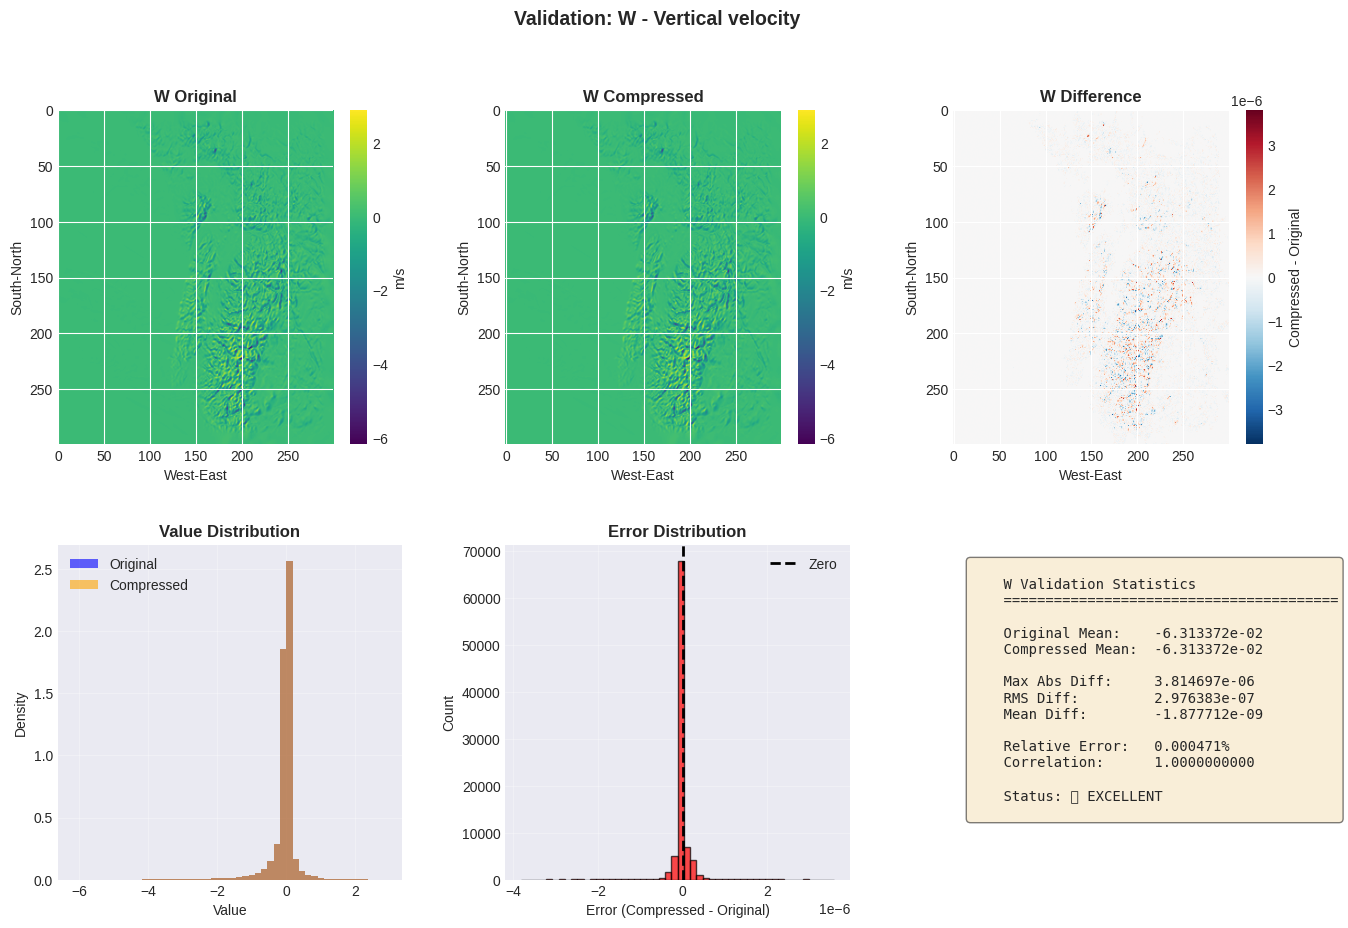


Plotting PSFC...


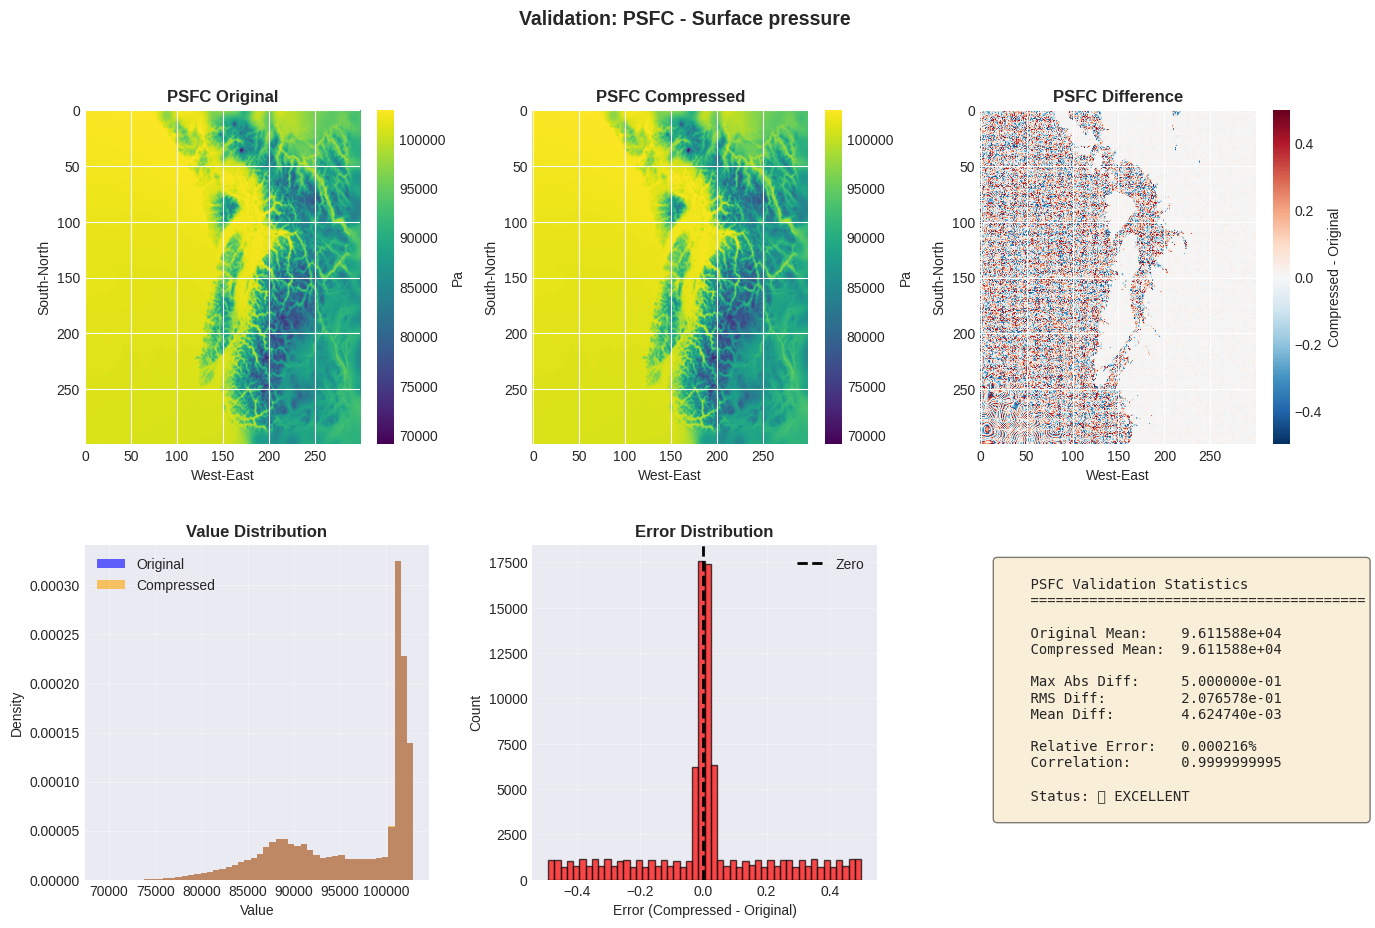


Plotting QVAPOR...


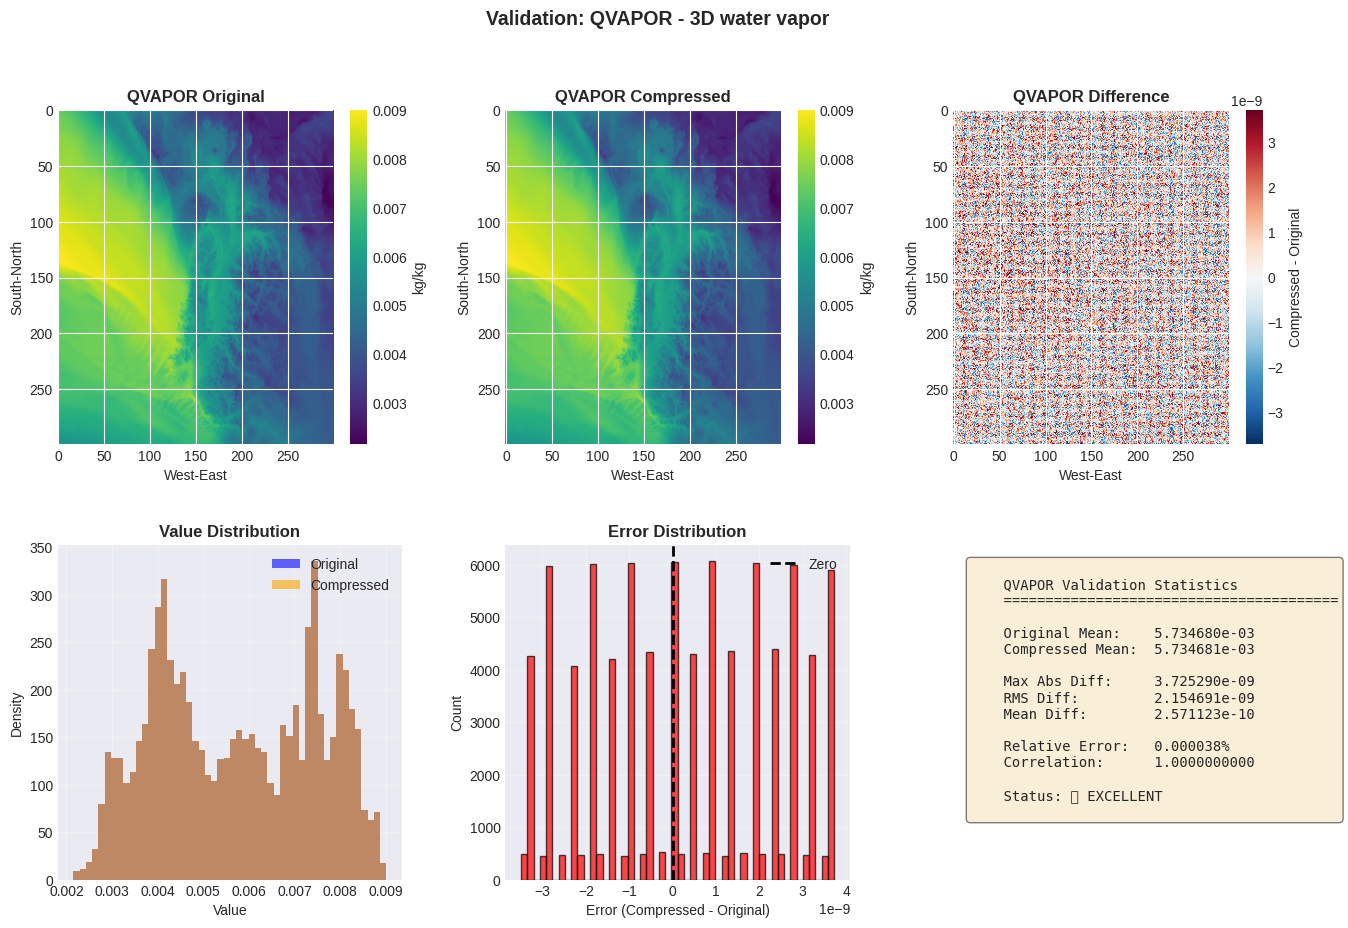


Plotting T2...


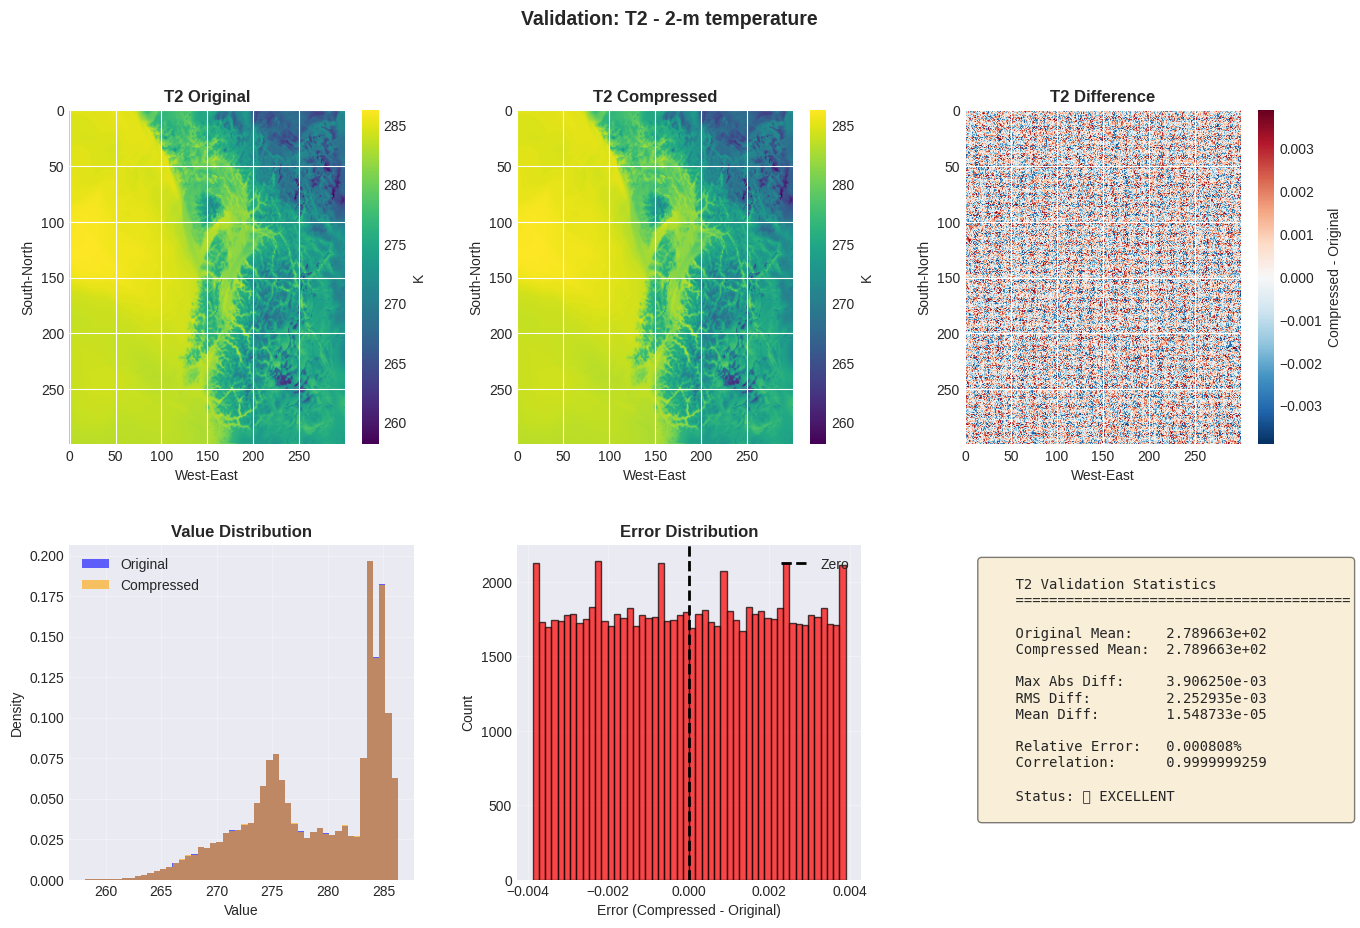


Plotting U10...


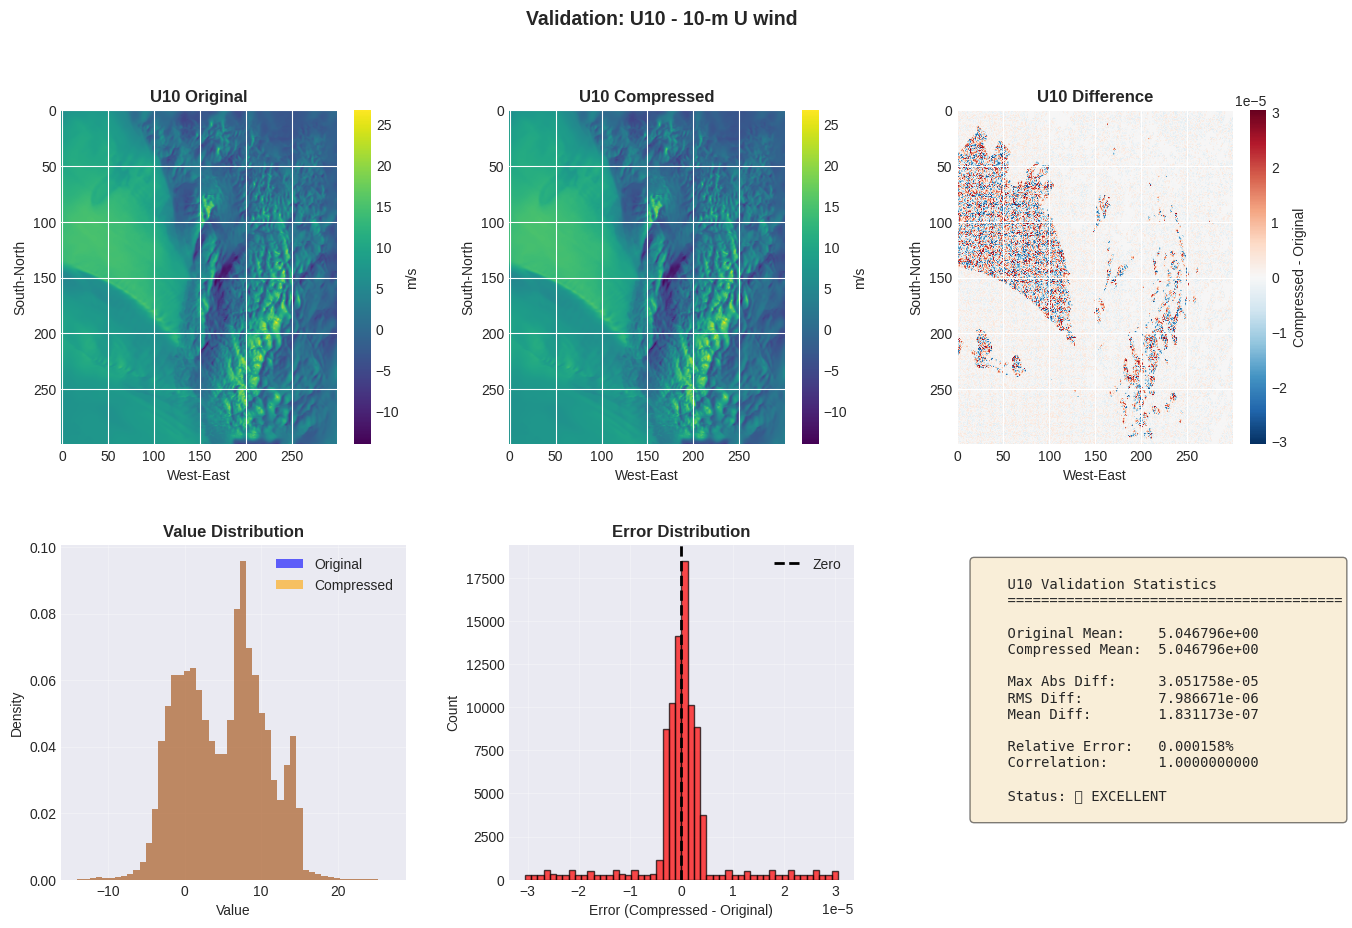


Plotting V10...


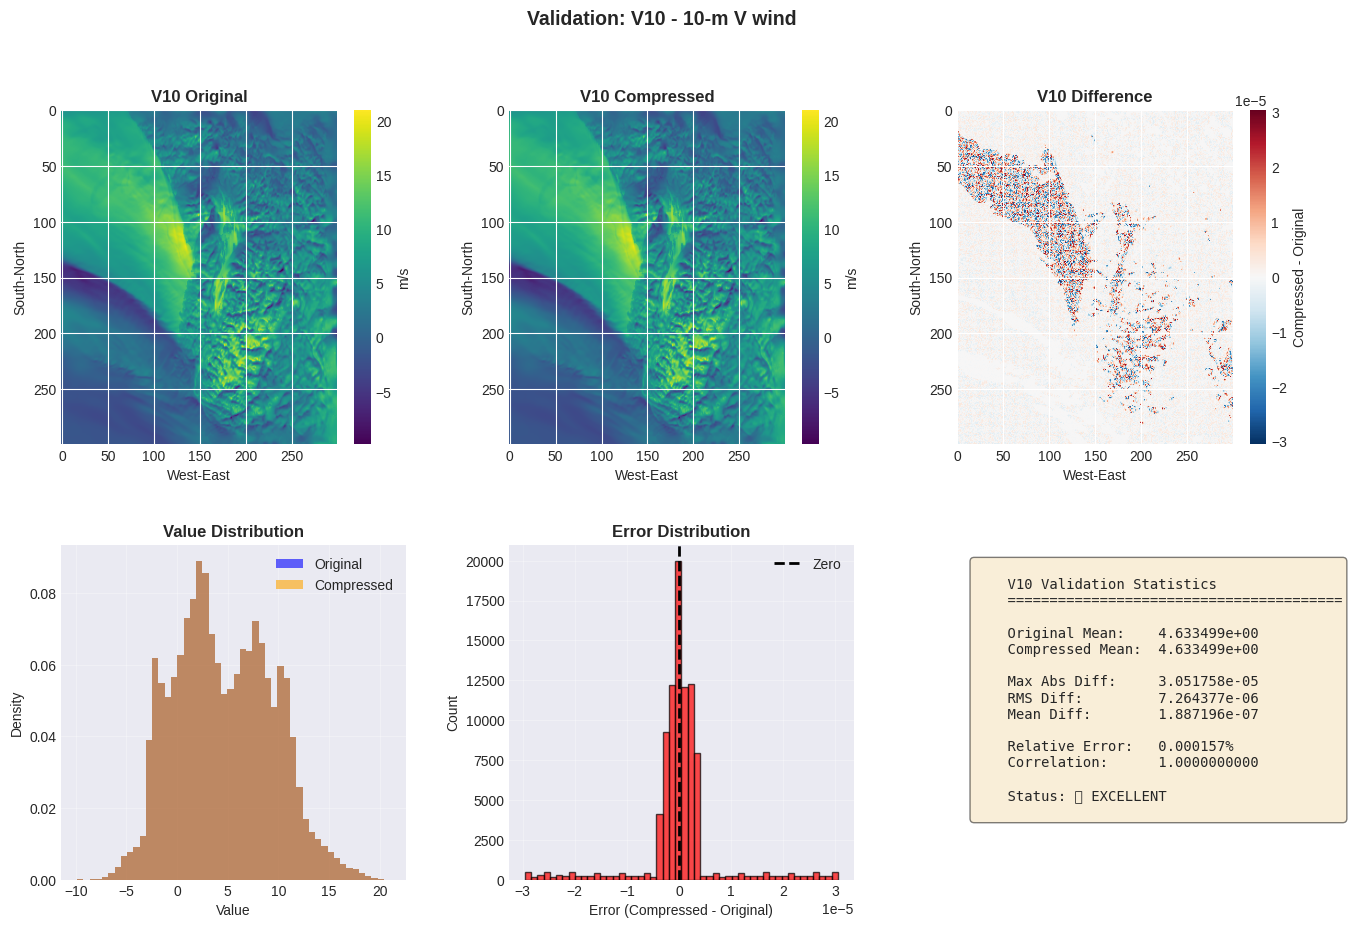


Plotting ACSWDNT...


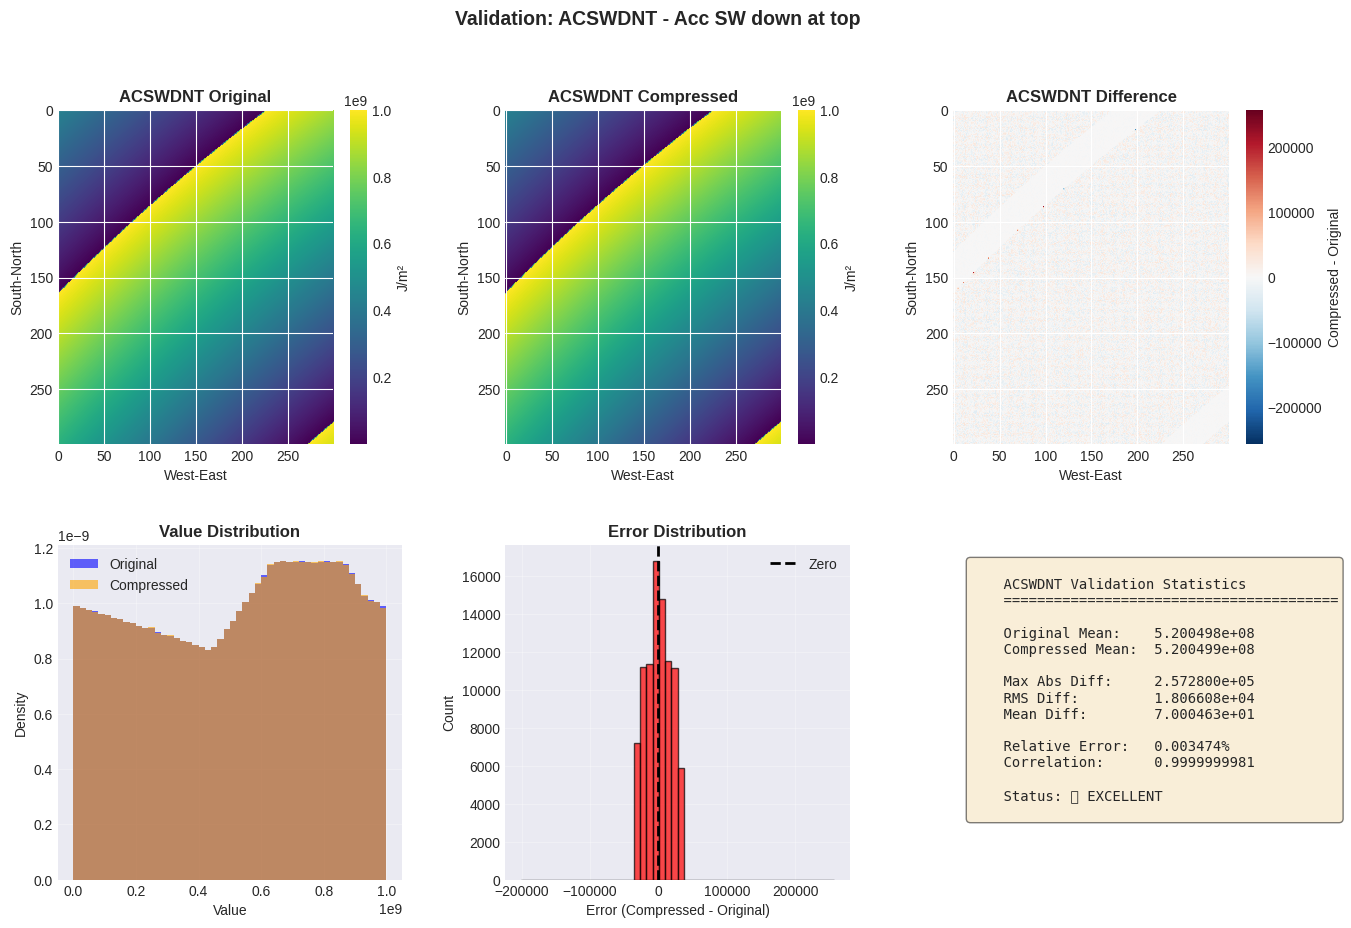

In [16]:
# Plot key variables
print("\n" + "="*100)
print("GENERATING VALIDATION PLOTS")
print("="*100)

key_vars_to_plot = ['W', 'PSFC', 'QVAPOR', 'T2', 'U10', 'V10', 'ACSWDNT']

for var in key_vars_to_plot:
    if var in orig and var in comp:
        print(f"\nPlotting {var}...")
        plot_variable_validation(var, orig, comp)
    else:
        print(f"⚠️  {var} not available")

In [17]:
# ============================================================================
# FINAL SUMMARY
# ============================================================================

print("\n" + "="*100)
print("VALIDATION SUMMARY REPORT")
print("="*100)

# Count by status
excellent_count = sum(1 for r in results.values() if '✅ EXCELLENT' in r['status'])
good_count = sum(1 for r in results.values() if '✅ GOOD' in r['status'])
check_count = sum(1 for r in results.values() if '⚠️' in r['status'])

print(f"\n📊 Variables Validated: {len(results)}")
print(f"   ✅ EXCELLENT: {excellent_count}")
print(f"   ✅ GOOD:      {good_count}")
print(f"   ⚠️  CHECK:    {check_count}")

# Critical variables
print("\n" + "-"*100)
print("🎯 CRITICAL VARIABLES FOR STORM ANALYSIS:")
print("-"*100)

critical_vars = {k: v for k, v in results.items() if v['info']['importance'] == 'CRITICAL'}

all_critical_good = True
for var, res in sorted(critical_vars.items()):
    status_symbol = "✅" if "✅" in res['status'] else "⚠️"
    print(f"  {status_symbol} {var:<12} - {res['info']['description']:<40} [{res['status']}]")
    if "⚠️" in res['status']:
        all_critical_good = False

# Derived quantities
if derived_results:
    print("\n" + "-"*100)
    print("🔬 DERIVED QUANTITIES:")
    print("-"*100)
    for name, res in derived_results.items():
        status_symbol = "✅" if "✅" in res['status'] else "⚠️"
        print(f"  {status_symbol} {name:<25} [{res['status']}]")

# Terrain checks
if terrain_results:
    print("\n" + "-"*100)
    print("🏔️  COMPLEX TERRAIN CHECKS:")
    print("-"*100)
    for name, res in terrain_results.items():
        status_symbol = "✅" if "✅" in res['status'] else "⚠️"
        print(f"  {status_symbol} {name:<25} [{res['status']}]")

# Overall assessment
print("\n" + "="*100)
if all_critical_good and check_count == 0:
    print("🎉 VALIDATION PASSED")
    print("   All variables are suitable for storm analysis in complex terrain.")
    print("   Your compression settings preserve scientific integrity.")
elif all_critical_good:
    print("✅ VALIDATION MOSTLY PASSED")
    print("   Critical variables are good. Review flagged variables.")
    print("   Core storm analysis should be sound.")
else:
    print("⚠️  VALIDATION HAS CONCERNS")
    print("   Some critical variables flagged. Review results carefully.")
    print("   Consider increasing precision for flagged variables.")
print("="*100)


VALIDATION SUMMARY REPORT

📊 Variables Validated: 20
   ✅ EXCELLENT: 20
   ✅ GOOD:      0
   ⚠️  CHECK:    0

----------------------------------------------------------------------------------------------------
🎯 CRITICAL VARIABLES FOR STORM ANALYSIS:
----------------------------------------------------------------------------------------------------
  ✅ P            - Pressure perturbation                    [✅ EXCELLENT]
  ✅ PH           - Geopotential perturbation                [✅ EXCELLENT]
  ✅ PSFC         - Surface pressure                         [✅ EXCELLENT]
  ✅ Q2           - 2-m mixing ratio                         [✅ EXCELLENT]
  ✅ QVAPOR       - 3D water vapor                           [✅ EXCELLENT]
  ✅ T            - Potential temperature                    [✅ EXCELLENT]
  ✅ T2           - 2-m temperature                          [✅ EXCELLENT]
  ✅ U10          - 10-m U wind                              [✅ EXCELLENT]
  ✅ V10          - 10-m V wind                        

## Check for Terracing
Terracing is when smooth spatial gradients in a WRF variable (like temperature or humidity) become visible stepped bands because lossy compression quantizes subtly differing values into the same discrete level.


TERRACING / QUANTIZATION ARTIFACT CHECK

Checking key variables for terracing artifacts...

T2:
------------------------------------------------------------
  Unique values:
    Original:   80,236
    Compressed: 3,165
    Ratio:      0.0394
    ⚠️  WARNING: Significant loss of unique values (terracing likely)
  Plot saved: terracing_check_T2.png


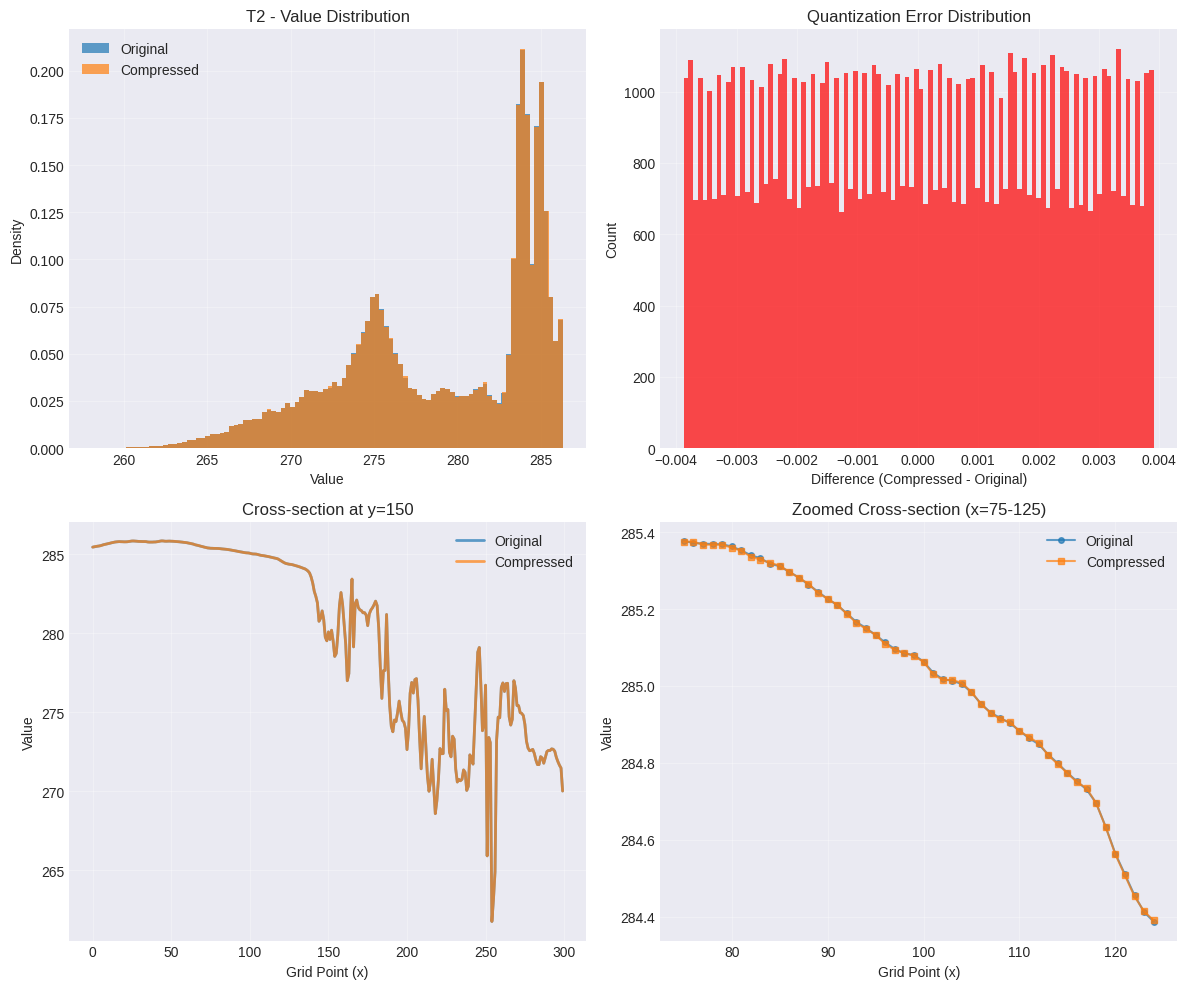

  Gradient smoothness (2nd derivative std):
    Original:   7.816103e-01
    Compressed: 7.814699e-01
    Ratio:      0.9998
    ✅ Smoothness well preserved
  High-frequency content ratio: 0.9999
    ✅ Frequency content preserved

PSFC:
------------------------------------------------------------
  Unique values:
    Original:   85,772
    Compressed: 43,548
    Ratio:      0.5077
    ✅ Good retention of unique values
  Plot saved: terracing_check_PSFC.png


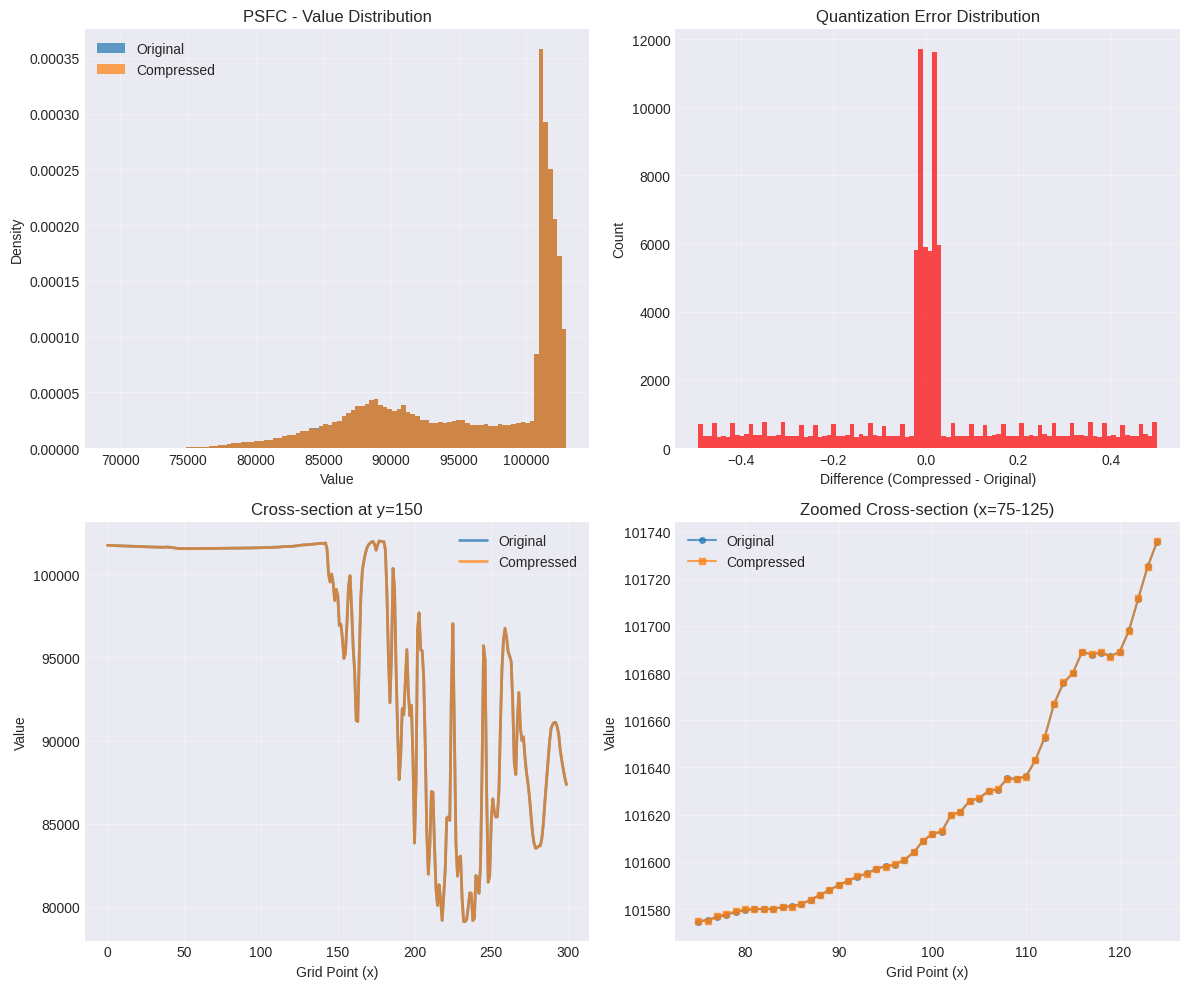

  Gradient smoothness (2nd derivative std):
    Original:   1.138729e+03
    Compressed: 1.138725e+03
    Ratio:      1.0000
    ✅ Smoothness well preserved
  High-frequency content ratio: 1.0000
    ✅ Frequency content preserved

Q2:
------------------------------------------------------------
  Unique values:
    Original:   89,634
    Compressed: 84,756
    Ratio:      0.9456
    ✅ Good retention of unique values
  Plot saved: terracing_check_Q2.png


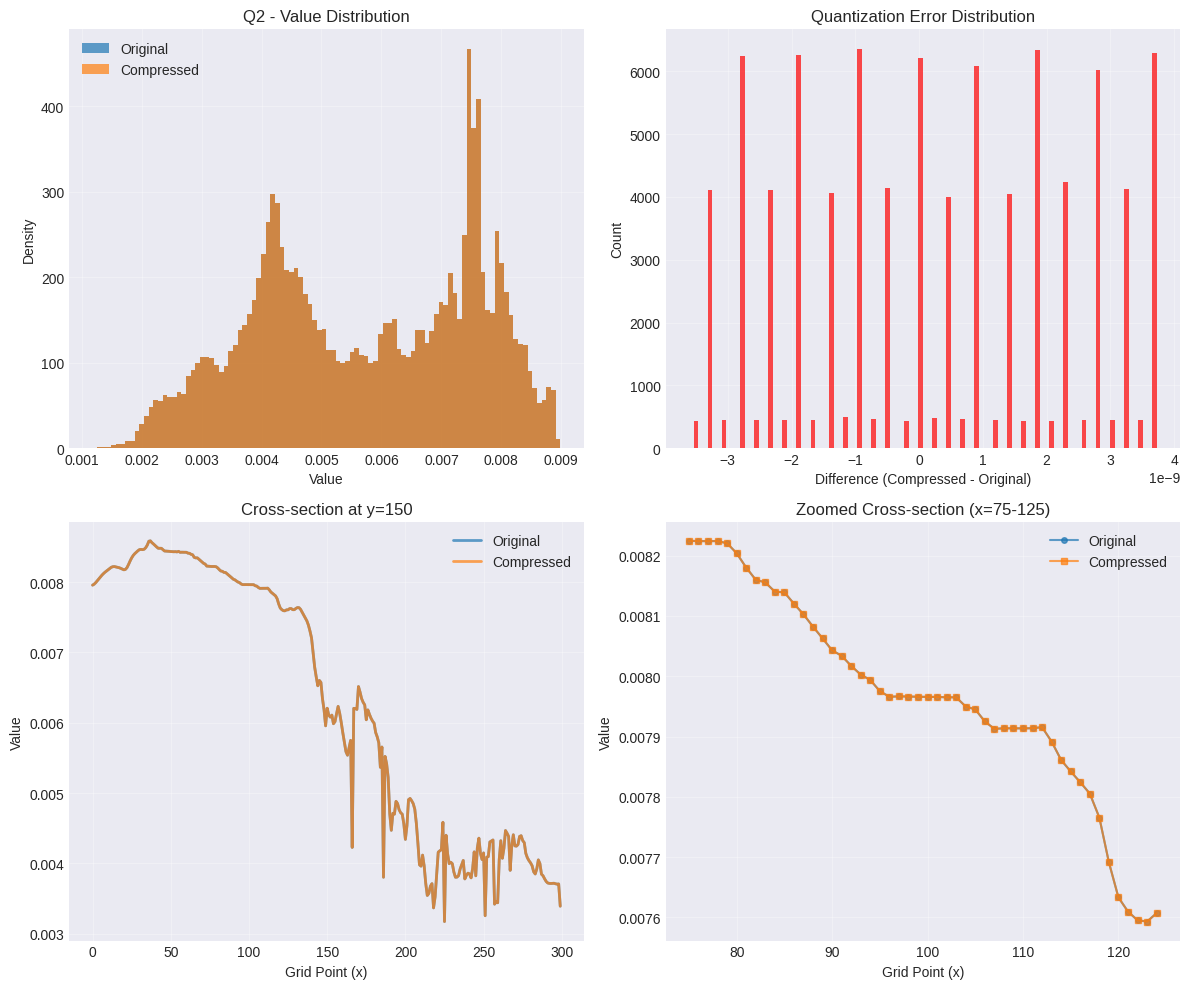

  Gradient smoothness (2nd derivative std):
    Original:   1.182383e-04
    Compressed: 1.182381e-04
    Ratio:      1.0000
    ✅ Smoothness well preserved
  High-frequency content ratio: 1.0000
    ✅ Frequency content preserved

T:
------------------------------------------------------------
  Unique values:
    Original:   74,283
    Compressed: 17,847
    Ratio:      0.2403
    ⚠️  CAUTION: Moderate loss of unique values
  Plot saved: terracing_check_T.png


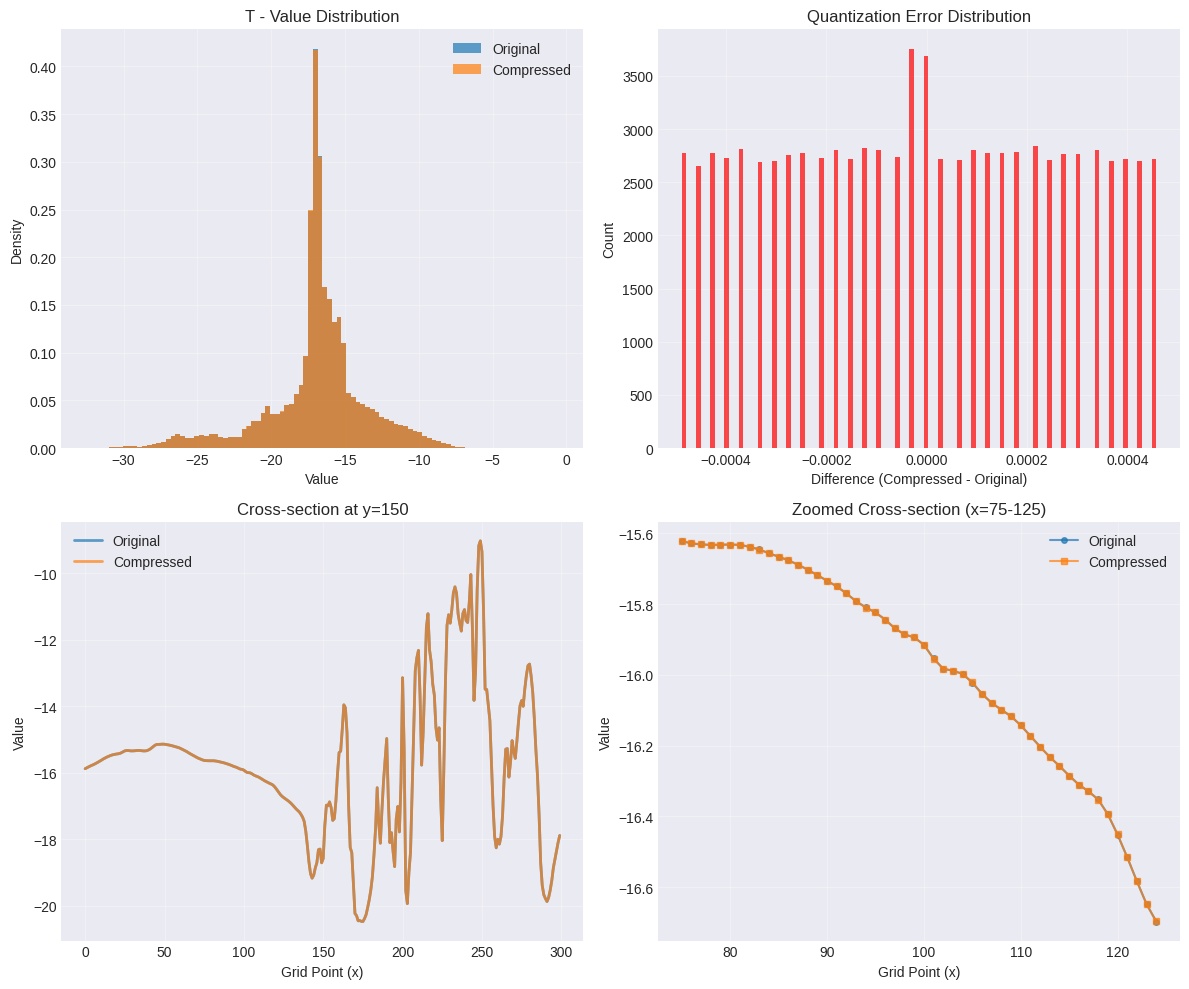

  Gradient smoothness (2nd derivative std):
    Original:   4.307366e-01
    Compressed: 4.307482e-01
    Ratio:      1.0000
    ✅ Smoothness well preserved
  High-frequency content ratio: 1.0000
    ✅ Frequency content preserved

TERRACING SUMMARY
Variable        Unique Ratio    Roughness       High-Freq       Status    
----------------------------------------------------------------------
T2              0.0394          0.9998          0.9999          ⚠️  Caution
PSFC            0.5077          1.0000          1.0000          ✅ Good    
Q2              0.9456          1.0000          1.0000          ✅ Good    
T               0.2403          1.0000          1.0000          ⚠️  Caution


In [18]:

from scipy import stats


print("\n" + "="*70)
print("TERRACING / QUANTIZATION ARTIFACT CHECK")
print("="*70)

def check_terracing(varname, orig_ds, comp_ds, time_idx=0, level_idx=None):
    """
    Check for terracing artifacts by analyzing:
    1. Number of unique values (should not decrease dramatically)
    2. Histogram of values (should not show artificial peaks)
    3. Visual inspection of cross-sections
    4. Gradient smoothness
    """
    print(f"\n{varname}:")
    print("-" * 60)
    
    # Get data
    orig_var = orig_ds[varname]
    comp_var = comp_ds[varname]
    
    # Select appropriate slice
    if orig_var.ndim == 4:  # (time, z, y, x)
        if level_idx is not None:
            orig_data = orig_var.values[time_idx, level_idx, :, :]
            comp_data = comp_var.values[time_idx, level_idx, :, :]
        else:
            orig_data = orig_var.values[time_idx, 0, :, :]
            comp_data = comp_var.values[time_idx, 0, :, :]
    elif orig_var.ndim == 3:  # (time, y, x)
        orig_data = orig_var.values[time_idx, :, :]
        comp_data = comp_var.values[time_idx, :, :]
    else:
        orig_data = orig_var.values
        comp_data = comp_var.values
    
    # Flatten for statistics
    orig_flat = orig_data.flatten()
    comp_flat = comp_data.flatten()
    
    # Remove NaNs
    orig_flat = orig_flat[np.isfinite(orig_flat)]
    comp_flat = comp_flat[np.isfinite(comp_flat)]
    
    # 1. Count unique values
    n_unique_orig = len(np.unique(orig_flat))
    n_unique_comp = len(np.unique(comp_flat))
    unique_ratio = n_unique_comp / n_unique_orig if n_unique_orig > 0 else 0
    
    print(f"  Unique values:")
    print(f"    Original:   {n_unique_orig:,}")
    print(f"    Compressed: {n_unique_comp:,}")
    print(f"    Ratio:      {unique_ratio:.4f}")
    
    if unique_ratio < 0.1:
        print(f"    ⚠️  WARNING: Significant loss of unique values (terracing likely)")
    elif unique_ratio < 0.5:
        print(f"    ⚠️  CAUTION: Moderate loss of unique values")
    else:
        print(f"    ✅ Good retention of unique values")
    
    # 2. Histogram comparison
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    
    # Histogram of values
    axes[0, 0].hist(orig_flat, bins=100, alpha=0.7, label='Original', density=True)
    axes[0, 0].hist(comp_flat, bins=100, alpha=0.7, label='Compressed', density=True)
    axes[0, 0].set_xlabel('Value')
    axes[0, 0].set_ylabel('Density')
    axes[0, 0].set_title(f'{varname} - Value Distribution')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # Difference histogram
    diff = comp_flat - orig_flat[:len(comp_flat)]
    axes[0, 1].hist(diff, bins=100, alpha=0.7, color='red')
    axes[0, 1].set_xlabel('Difference (Compressed - Original)')
    axes[0, 1].set_ylabel('Count')
    axes[0, 1].set_title('Quantization Error Distribution')
    axes[0, 1].grid(True, alpha=0.3)
    
    # 3. Cross-section comparison (horizontal slice)
    mid_y = orig_data.shape[0] // 2
    orig_slice = orig_data[mid_y, :]
    comp_slice = comp_data[mid_y, :]
    
    axes[1, 0].plot(orig_slice, label='Original', alpha=0.7, linewidth=2)
    axes[1, 0].plot(comp_slice, label='Compressed', alpha=0.7, linewidth=2)
    axes[1, 0].set_xlabel('Grid Point (x)')
    axes[1, 0].set_ylabel('Value')
    axes[1, 0].set_title(f'Cross-section at y={mid_y}')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
    
    # Zoom on a section to see terracing
    zoom_start = len(orig_slice) // 4
    zoom_end = zoom_start + 50
    axes[1, 1].plot(range(zoom_start, zoom_end), 
                    orig_slice[zoom_start:zoom_end], 
                    'o-', label='Original', markersize=4, alpha=0.7)
    axes[1, 1].plot(range(zoom_start, zoom_end), 
                    comp_slice[zoom_start:zoom_end], 
                    's-', label='Compressed', markersize=4, alpha=0.7)
    axes[1, 1].set_xlabel('Grid Point (x)')
    axes[1, 1].set_ylabel('Value')
    axes[1, 1].set_title(f'Zoomed Cross-section (x={zoom_start}-{zoom_end})')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(f'terracing_check_{varname}.png', dpi=150, bbox_inches='tight')
    print(f"  Plot saved: terracing_check_{varname}.png")
    plt.show()
    
    # 4. Gradient smoothness test
    # Compute second derivative (measure of smoothness)
    grad_orig = np.gradient(orig_slice)
    grad_comp = np.gradient(comp_slice)
    
    grad2_orig = np.gradient(grad_orig)
    grad2_comp = np.gradient(grad_comp)
    
    # Roughness measure: standard deviation of second derivative
    roughness_orig = np.nanstd(grad2_orig)
    roughness_comp = np.nanstd(grad2_comp)
    roughness_ratio = roughness_comp / roughness_orig if roughness_orig > 0 else 0
    
    print(f"  Gradient smoothness (2nd derivative std):")
    print(f"    Original:   {roughness_orig:.6e}")
    print(f"    Compressed: {roughness_comp:.6e}")
    print(f"    Ratio:      {roughness_ratio:.4f}")
    
    if roughness_ratio > 2.0:
        print(f"    ⚠️  WARNING: Compressed field is significantly rougher (terracing)")
    elif roughness_ratio > 1.5:
        print(f"    ⚠️  CAUTION: Some increase in roughness")
    else:
        print(f"    ✅ Smoothness well preserved")
    
    # 5. Power spectrum analysis (frequency content)
    from numpy.fft import fft, fftfreq
    
    # Remove mean for FFT
    orig_fft = np.abs(fft(orig_slice - np.mean(orig_slice)))
    comp_fft = np.abs(fft(comp_slice - np.mean(comp_slice)))
    
    # High-frequency content (upper 25% of frequencies)
    n = len(orig_fft)
    high_freq_start = n * 3 // 4
    
    high_freq_orig = np.mean(orig_fft[high_freq_start:])
    high_freq_comp = np.mean(comp_fft[high_freq_start:])
    high_freq_ratio = high_freq_comp / high_freq_orig if high_freq_orig > 0 else 0
    
    print(f"  High-frequency content ratio: {high_freq_ratio:.4f}")
    if high_freq_ratio > 2.0:
        print(f"    ⚠️  WARNING: Increased high-frequency noise (possible terracing)")
    elif high_freq_ratio > 1.5:
        print(f"    ⚠️  CAUTION: Some high-frequency increase")
    else:
        print(f"    ✅ Frequency content preserved")
    
    return {
        'unique_ratio': unique_ratio,
        'roughness_ratio': roughness_ratio,
        'high_freq_ratio': high_freq_ratio
    }

# Check key variables
results = {}

print("\nChecking key variables for terracing artifacts...")

if 'T2' in orig:
    results['T2'] = check_terracing('T2', orig, comp)

if 'PSFC' in orig:
    results['PSFC'] = check_terracing('PSFC', orig, comp)

if 'Q2' in orig:
    results['Q2'] = check_terracing('Q2', orig, comp)

if 'T' in orig:
    results['T'] = check_terracing('T', orig, comp, level_idx=0)

# Summary
print("\n" + "="*70)
print("TERRACING SUMMARY")
print("="*70)
print(f"{'Variable':<15} {'Unique Ratio':<15} {'Roughness':<15} {'High-Freq':<15} {'Status':<10}")
print("-"*70)

for var, res in results.items():
    # Determine status
    issues = 0
    if res['unique_ratio'] < 0.5:
        issues += 1
    if res['roughness_ratio'] > 1.5:
        issues += 1
    if res['high_freq_ratio'] > 1.5:
        issues += 1
    
    if issues == 0:
        status = "✅ Good"
    elif issues == 1:
        status = "⚠️  Caution"
    else:
        status = "❌ Warning"
    
    print(f"{var:<15} {res['unique_ratio']:<15.4f} {res['roughness_ratio']:<15.4f} "
          f"{res['high_freq_ratio']:<15.4f} {status:<10}")

print("="*70)

orig.close()
comp.close()